<a href="https://colab.research.google.com/github/Architag1503/Colab/blob/main/HiddenMarkovDecisionProcess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


🔬 Processing: human.txt
Length analyzed: 5000
Coding Regions: 4187
Non-Coding Regions: 813


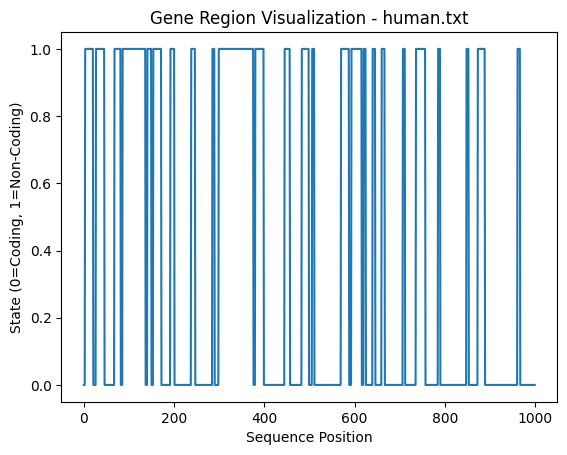

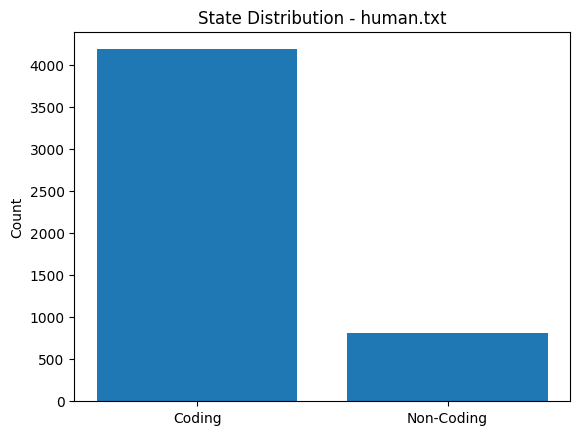


🔬 Processing: dog.txt
Length analyzed: 5000
Coding Regions: 4073
Non-Coding Regions: 927


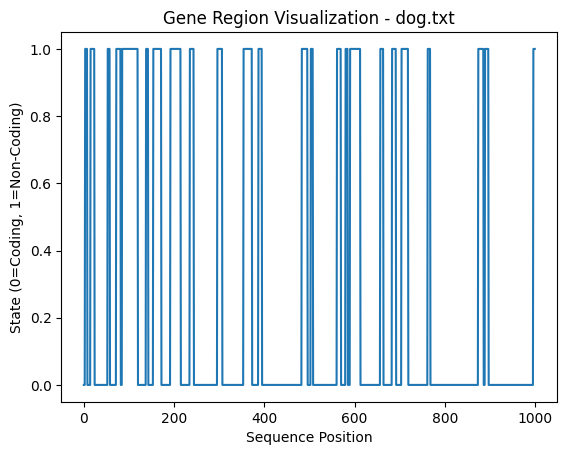

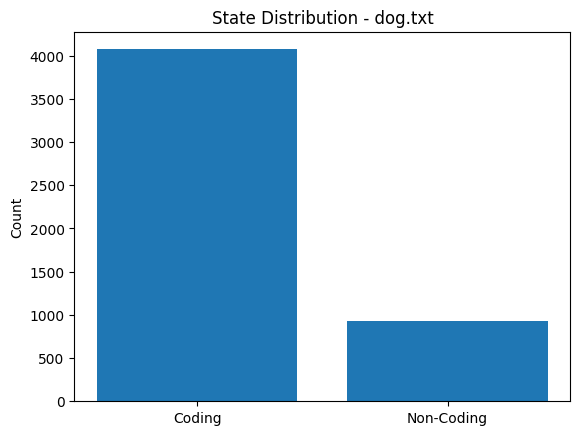


🔬 Processing: chimpanzee.txt
Length analyzed: 5000
Coding Regions: 3947
Non-Coding Regions: 1053


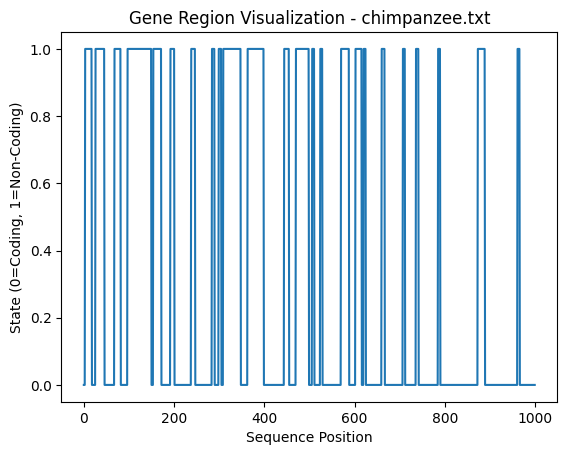

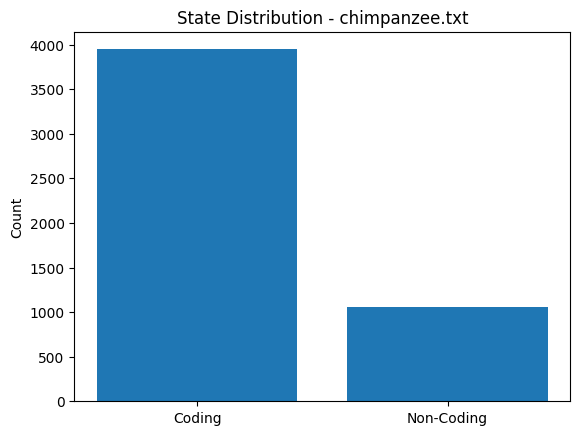

In [2]:
import numpy as np
import zipfile
import os
import matplotlib.pyplot as plt

# =========================
# 1. Load DNA Sequences
# =========================
def load_sequences(zip_path):

    extract_path = "/content/dna_data"

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    sequences = {}

    for file in os.listdir(extract_path):
        if file.endswith(".txt"):
            with open(os.path.join(extract_path, file), 'r') as f:
                seq = f.read().replace("\n", "").strip()
                sequences[file] = seq

    return sequences


# =========================
# 2. Encode DNA
# =========================
def encode_sequence(seq):
    mapping = {'A':0, 'T':1, 'G':2, 'C':3}
    return np.array([mapping[ch] for ch in seq if ch in mapping])


# =========================
# 3. Initialize HMM
# =========================
def initialize_hmm():

    pi = np.array([0.5, 0.5])

    A = np.array([
        [0.7, 0.3],
        [0.4, 0.6]
    ])

    B = np.array([
        [0.2, 0.3, 0.3, 0.2],
        [0.3, 0.2, 0.2, 0.3]
    ])

    return pi, A, B


# =========================
# 4. Viterbi Algorithm
# =========================
def viterbi(obs, pi, A, B):

    T = len(obs)
    N = len(pi)

    dp = np.zeros((N, T))
    ptr = np.zeros((N, T), dtype=int)

    dp[:, 0] = np.log(pi) + np.log(B[:, obs[0]])

    for t in range(1, T):
        for j in range(N):
            probs = dp[:, t-1] + np.log(A[:, j]) + np.log(B[j, obs[t]]
            )
            ptr[j, t] = np.argmax(probs)
            dp[j, t] = np.max(probs)

    states = np.zeros(T, dtype=int)
    states[-1] = np.argmax(dp[:, -1])

    for t in range(T-2, -1, -1):
        states[t] = ptr[states[t+1], t+1]

    return states


# =========================
# 5. Visualization
# =========================
def visualize_states(states, name):

    # Limit for visualization
    states = states[:1000]

    plt.figure()

    plt.title(f"Gene Region Visualization - {name}")

    plt.plot(states)

    plt.xlabel("Sequence Position")
    plt.ylabel("State (0=Coding, 1=Non-Coding)")

    plt.show()


def plot_distribution(states, name):

    coding = np.sum(states == 0)
    noncoding = np.sum(states == 1)

    plt.figure()

    plt.title(f"State Distribution - {name}")
    plt.bar(["Coding", "Non-Coding"], [coding, noncoding])

    plt.ylabel("Count")

    plt.show()


# =========================
# 6. Analysis
# =========================
def analyze_sequence(name, seq, pi, A, B):

    print(f"\n🔬 Processing: {name}")

    encoded = encode_sequence(seq)
    encoded = encoded[:5000]

    states = viterbi(encoded, pi, A, B)

    coding_count = np.sum(states == 0)
    noncoding_count = np.sum(states == 1)

    print(f"Length analyzed: {len(encoded)}")
    print(f"Coding Regions: {coding_count}")
    print(f"Non-Coding Regions: {noncoding_count}")

    # Visualizations
    visualize_states(states, name)
    plot_distribution(states, name)


# =========================
# MAIN
# =========================
if __name__ == "__main__":

    zip_path = "/content/drive/MyDrive/dataset/archive (4).zip"

    sequences = load_sequences(zip_path)

    pi, A, B = initialize_hmm()

    for name, seq in sequences.items():
        analyze_sequence(name, seq, pi, A, B)